In [1]:
##### SI Figure 2: sub-national capital and labor intensities

from pathlib import Path
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib import cm

In [2]:
##### Load data

# Get the current working directory
cd = Path.cwd().parent.parent

# sub-national data 
sub_national_capital = pd.read_csv(f"{cd}/Data/Clean/Intensities/subnational_capital_intensity.csv")
sub_national_labor = pd.read_csv(f"{cd}/Data/Clean/Intensities/subnational_labor_intensity.csv")
sub_national_capital_geo = gpd.read_file(f"{cd}/Data/Clean/Geographies/subnational_capital.shp")
sub_national_labor_geo = gpd.read_file(f"{cd}/Data/Clean/Geographies/subnational_labor.shp")

# national data
country_intensities = pd.read_csv(f"{cd}/Data/Clean/Intensities/country_intensities.csv")
country_boundaries = gpd.read_file(f"{cd}/Data/Clean/Geographies/country_geo.shp")

has_data = pd.read_csv(f'{cd}/Data/Correspondence_tables/has_data.csv')

# Set file path to figure repo
fd = "/Users/carinamanitius/Library/CloudStorage/OneDrive-UniversityofVermont/Documents/OneDrive/Dissertation/Chapter 1/Figures/FINAL_FIGURES"

In [3]:
### Data prep

target_crs = "+proj=eck4 +lon_0=0 +x_0=0 +y_0=0 +datum=WGS84 +units=m +no_defs"

country_boundaries = country_boundaries.to_crs(target_crs)
sub_national_capital_geo = sub_national_capital_geo.to_crs(target_crs)
sub_national_labor_geo = sub_national_labor_geo.to_crs(target_crs)

# add geo to country / sub-national intensities 
country_boundaries = country_boundaries.merge(country_intensities, on='ISO3', how='left')

sub_national_capital = sub_national_capital_geo.merge(sub_national_capital, on='PROJ_ID', how='left')
sub_national_labor = sub_national_labor_geo.merge(sub_national_labor, on='PROJ_ID', how='left')

# identify no data countries 

country_boundaries = country_boundaries.merge(has_data, on='SHP_code', how='left')
country_boundaries['has_capital_data'] = country_boundaries['has_capital_data'].fillna(0)
country_boundaries['has_labor_data'] = country_boundaries['has_labor_data'].fillna(0)

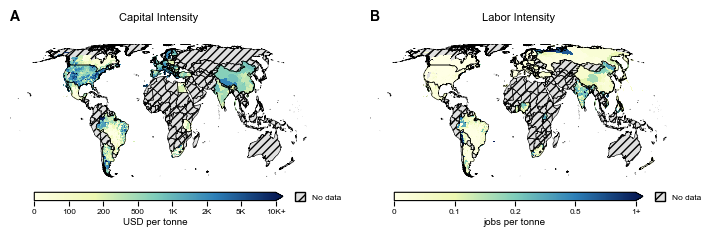

In [5]:
#### Map sub-national intensities side-by-side

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],
})


def plot_subnational_capital_labor(
    capital_gdf, labor_gdf, country_gdf,
    capital_col, labor_col,
    capital_bounds, capital_labels, capital_cbar_label,
    labor_bounds, labor_labels, labor_cbar_label,
    out_path, missing_color="#e0e0e0"
):

    minx, miny, maxx, maxy = country_gdf.total_bounds

    # --- Custom white -> YlGnBu colormap (shared with other intensity maps) ---
    cmap = mcolors.LinearSegmentedColormap.from_list(
        "white_ylgnbu",
        ["#ffffe5", "#edf8b1", "#7fcdbb", "#2c7fb8", "#081d58"]
    )
    cmap.set_over("#081d58")

    # --- Piecewise-linear scaling helpers ---
    def make_norm(bounds):
        positions = np.linspace(0, 1, len(bounds))

        def forward(x, bounds=bounds, positions=positions):
            return np.interp(x, bounds, positions)

        def inverse(x, bounds=bounds, positions=positions):
            return np.interp(x, positions, bounds)

        return mcolors.FuncNorm((forward, inverse), vmin=bounds[0], vmax=bounds[-1])

    capital_norm = make_norm(capital_bounds)
    labor_norm = make_norm(labor_bounds)

    # --- Compute figure height from actual data aspect ratio, sized to
    # double-column print width so specified point sizes are what prints ---
    data_w = maxx - minx
    data_h = maxy - miny
    fig_width = 7.2
    panel_width = fig_width / 2
    map_height = panel_width * (data_h / data_w)
    fig_height = map_height + 0.6

    fig, axes = plt.subplots(1, 2, figsize=(fig_width, fig_height), layout="constrained")
    # Main title removed — belongs in the caption. Sub-panel titles kept.

    panel_letters = ["A", "B"]
    panel_specs = [
        (axes[0], capital_gdf, capital_col, capital_norm, "Capital Intensity"),
        (axes[1], labor_gdf, labor_col, labor_norm, "Labor Intensity"),
    ]

    for letter, (ax, gdf, value_col, norm, panel_title) in zip(panel_letters, panel_specs):
        # background: fill ALL countries with the no-data hatch first; sub-national
        # polygons with data draw on top and cover it up wherever they exist
        country_gdf.plot(ax=ax, facecolor=missing_color, edgecolor="none", hatch="////", zorder=1)

        gdf.plot(
            ax=ax, column=value_col, cmap=cmap, norm=norm,
            edgecolor="none", linewidth=0, antialiased=False, zorder=2
        )

        country_gdf.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=0.4, zorder=3)

        ax.set_xlim(minx, maxx)
        ax.set_ylim(miny, maxy)
        ax.set_aspect("equal")
        ax.set_axis_off()

        # Panel letter (left) + descriptive sub-title (center), both as real
        # axes titles so the layout engine accounts for them and can't overlap
        ax.set_title(letter, loc="left", fontsize=10, fontweight="bold")
        ax.set_title(panel_title, loc="center", fontsize=8)

    # --- Per-panel colorbar (each has its own units/scale), attached
    # directly to its axes so the layout engine places it automatically ---
    for ax, norm, bounds, labels, cbar_label in [
        (axes[0], capital_norm, capital_bounds, capital_labels, capital_cbar_label),
        (axes[1], labor_norm, labor_bounds, labor_labels, labor_cbar_label),
    ]:
        sm = cm.ScalarMappable(norm=norm, cmap=cmap)
        sm.set_array([])

        cbar = fig.colorbar(
            sm, ax=ax, orientation="horizontal", location="bottom",
            shrink=0.75, aspect=30, pad=0.06,
            extend='max', extendfrac=0.03,
        )
        cbar.set_label(cbar_label, fontsize=7, labelpad=2)
        cbar.ax.tick_params(labelsize=6, pad=2)
        cbar.set_ticks(bounds)
        cbar.set_ticklabels(labels)

        # --- Missing-data legend, anchored to the colorbar axis itself ---
        no_data_patch = mpatches.Patch(facecolor=missing_color, edgecolor="black",
                                        hatch="///", label="No data")
        cbar.ax.legend(handles=[no_data_patch], loc="center left",
                        bbox_to_anchor=(1.05, 0.5), frameon=False, fontsize=6,
                        handlelength=1.2, handleheight=1.2)

    fig.savefig(out_path, dpi=300, format="tiff")
    plt.show()


plot_subnational_capital_labor(
    capital_gdf=sub_national_capital,
    labor_gdf=sub_national_labor,
    country_gdf=country_boundaries,
    capital_col="capital_intensity_USD_per_tonne",
    labor_col="labor_intensity_jobs_per_tonne",
    capital_bounds=[0, 100, 200, 500, 1000, 2000, 5000, 10000],
    capital_labels=['0', '100', '200', '500', '1K', '2K', '5K', '10K+'],
    capital_cbar_label="USD per tonne",
    labor_bounds=[0, 0.1, 0.2, 0.5, 1],
    labor_labels=['0', '0.1', '0.2', '0.5', '1+'],
    labor_cbar_label="jobs per tonne",
    out_path=f"{fd}/SI_fig_2_subnational_intensities.tiff",
)